# fMRI · 00 · Dataset inspection — NSD Algonauts 2023
**Question:** is the dataset correctly loaded and image↔fMRI aligned?

Only *reads* the data through `src.data` — no training.

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
from src.data import build_datamodule
cfg = load_config('configs/fMRI/exp01_fmri_to_clip.yaml')
cfg['dataset']['root_dir']

project root: c:\Users\xxdia\Documents\TFM\TFM_REPOS_FINALES\tfm_fmri_eeg_diffusion


'C:/Users/xxdia/Documents/Datasets/NSD_Algonauts_2023'

In [2]:
dm = build_datamodule(cfg).prepare()
print('Subjects   :', dm.subjects)
print('Voxels/subj:', dm.voxel_counts)
for s in ('train','val','test'):
    print(f'{s:>5}: {len(dm.get_frame(s))} samples')

16:54:32 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
16:54:32 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}
Subjects   : ['subj01']
Voxels/subj: {'subj01': 39548}
train: 8857 samples
  val: 984 samples
 test: 159 samples


## Stimulus images

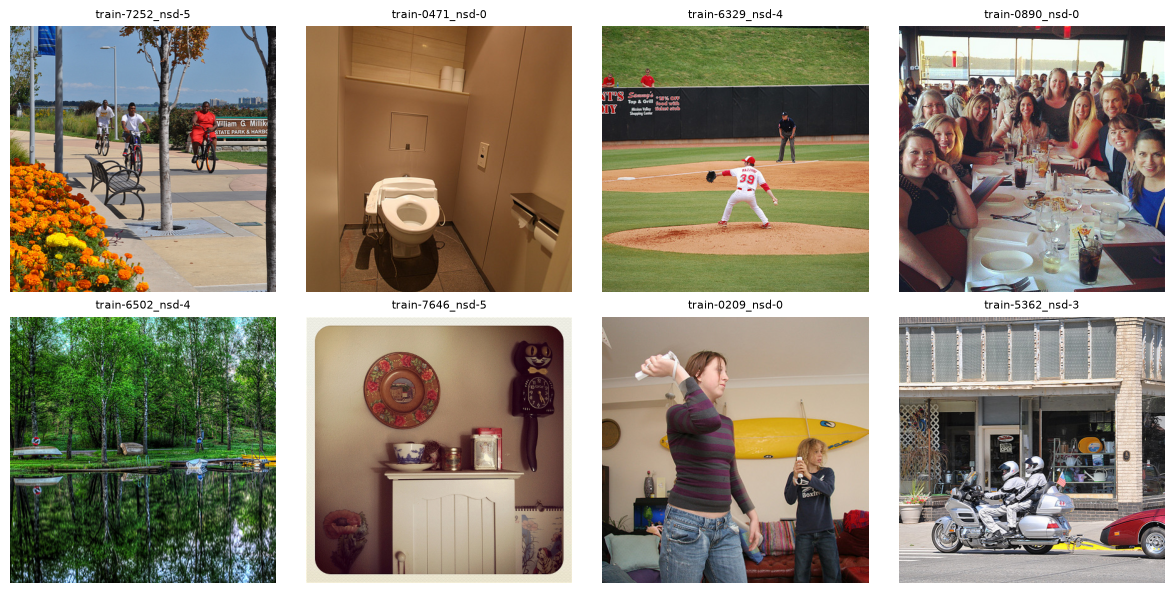

In [3]:
from src.data import load_image
frame = dm.get_frame('train')
sample = frame.sample(min(8, len(frame)), random_state=0)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(load_image(row.image_path)); ax.axis('off')
    ax.set_title(str(row.image_id)[:16], fontsize=8)
plt.tight_layout(); plt.show()

## fMRI distribution before / after normalization
Normalization is fitted on **train only** and reused for val/test.

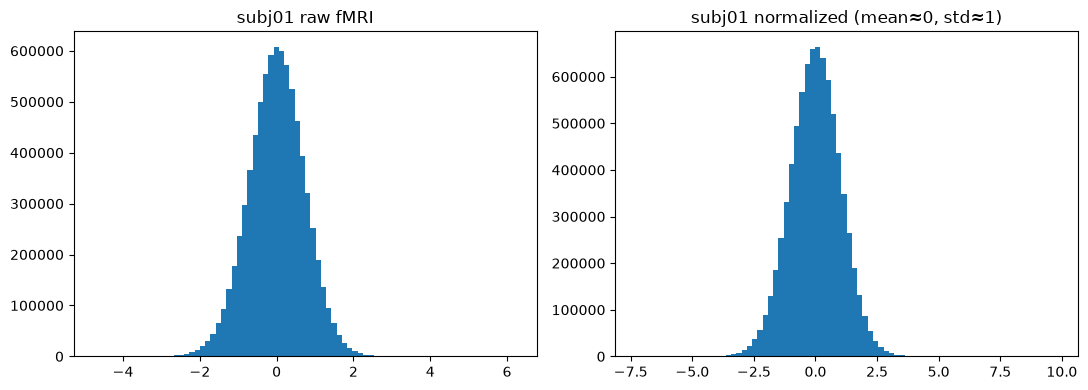

normalized mean -0.005 std 1.017


In [4]:
subj = dm.subjects[0]
reader = dm.subject_reader(subj); norm = dm.normalizer(subj)
tr = dm.subject_split_frame(subj, 'train')['local_index'].to_numpy()[:200]
raw = np.stack([reader.get_fmri(int(i)) for i in tr])
normed = norm.transform(raw)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(raw.ravel(), bins=80); ax[0].set_title(f'{subj} raw fMRI')
ax[1].hist(normed.ravel(), bins=80); ax[1].set_title(f'{subj} normalized (mean≈0, std≈1)')
plt.tight_layout(); plt.show()
print('normalized mean %.3f std %.3f' % (normed.mean(), normed.std()))

**Takeaway:** if subjects, split sizes and voxel counts look right and the normalized distribution is centered, the data is correctly loaded and aligned.